# Survey experiments

One report, four questions, in the order they have to be asked.

0. **What ran?** Which dataset, which horizon, and what training window Optuna
   selected -- including whether it selected it or merely ran out of grid.
1. **How often does each model pick the correct side**, in cross-validation and
   again on the untouched holdout? One chart, best run at the top.
2. **Does the model's own margin predict winning?** If the games it feels
   strongest about win more often, there is a threshold worth betting above. If
   they do not, selectivity only costs volume.
3. **What could you actually have bet?** The cutoff has to be chosen before the
   holdout is seen, so it is learned on CV, frozen, and applied unchanged.

ROI throughout is a flat `-110` translation of the same wins and losses. It is a
diagnostic, never a tuning objective and never a claim about executable
sportsbook returns -- the prediction artifacts do not retain per-bet prices.

In [1]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# Bootstrap. This one loop cannot move into training_pipeline, because
# training_pipeline is not importable until the repo root is on sys.path --
# and the notebook may be opened from its own directory or from the root.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Could not find the project root containing pyproject.toml.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.reporting import (  # noqa: E402
    alt_line, charts, coverage, loaders, narrative, theme,
)
from training_pipeline.reporting.discovery import load_runs  # noqa: E402

# ---------------------------------------------------------------------------
# What to survey
SOURCES: list[str] = ['experiments/target_total_points_2026_08', 'experiments/target_line_error_2026_08',
                      'experiments/horizon_line_error_2026_08', 'experiments/horizon_total_points_2026_08',
]
SOURCES: list[str] =[ 'experiments/grid_line_error_2026_08', 'experiments/grid_total_points_2026_08']
SOURCES = ['experiments/extended_history_cv_2026_09']
SOURCES = ['experiments/fixed50_optuna_2026_09']
ARTIFACTS_ROOT = 'artifacts/experiments'
ONLY_STRATEGIES: list[str] | None = None
ONLY_COMPARISON_GROUP: str | None = None

# Bet every game. No margin cutoff at all, on purpose: the headline sections
# measure the models at full volume, and section 4 is where selectivity gets
# put back and read deliberately. Anything below 1.00 here silently pre-filters
# the games that section 4 exists to study.
OPERATING_COVERAGE = 0.9

# Section 4 sweeps the top 100%, 90%, ... 10% of games by margin.
COVERAGE_GRID = coverage.COVERAGE_GRID
# 10 buckets over a ~415-game holdout is ~41 games each, already thin.
N_MARGIN_BUCKETS = 10
# Win-rate charts are focused on this band rather than 0-100%: break-even is
# 52.4% and nothing here has come near 70%. A floor, not a crop -- the axis
# widens automatically if a point would fall outside it.
WIN_RATE_YLIM = coverage.WIN_RATE_YLIM

# Section 6 only. Which snapshot line to re-settle closing-line models against.
# This dataset (unlike the 10snap totals-only one) carries a bare snapshot line
# for BOTH markets -- ODDS_TOTAL_LINE_bet365 and ODDS_SPREAD_LINE_HOME_bet365 --
# which is what lets section 6 re-settle spread runs as well as totals ones.
ALT_LINE_SNAPSHOT_MINUTES = 360
ALT_LINE_SNAPSHOT_CSV = 'data/train_data/intermediate_line_data_2_2_20260901.csv'
ALT_LINE_BOOK = 'bet365'
# ---------------------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
theme.apply_theme()

runs = theme.prepare_runs(
    load_runs(SOURCES, artifacts_root=ARTIFACTS_ROOT, project_root=PROJECT_ROOT)
)
if ONLY_STRATEGIES:
    runs = runs[runs['prediction_strategy'].isin(ONLY_STRATEGIES)]
if ONLY_COMPARISON_GROUP:
    runs = runs[runs['comparison_group'] == ONLY_COMPARISON_GROUP]
if runs.empty:
    raise ValueError('Every run was filtered out. Relax the filters above.')

# Adds panel_label (short, for charts), a prose label, and the metadata columns
# every later section keys off -- notably rows_per_game, which decides whether
# a confidence interval may be reported at all.
runs = theme.describe_runs(runs)
predictions = loaders.load_prediction_cache(runs)

# Win rate with NO threshold -- every prediction each run made, CV and holdout.
# Scored here so the inventory already answers "how often did it pick the right
# side?", and reused by section 1 rather than scoring every prediction twice.
scoreboard = coverage.build_scoreboard(runs, predictions)
# n_seeds / seed_roi_range come from seed_stability.csv and are 1 / NaN on a
# single-seed run. They belong next to the win rates: seed_roi_range is the
# spread of ONE config's own ROI across seeds, so any between-run gap smaller
# than it is not a result. A run with no extra seeds simply has no error bar.
inventory = runs[[
    'label', 'prediction_strategy', 'train_games', 'rows_per_game', 'created_at',

]].merge(
    scoreboard[[
        'label', 'cv_win_rate', 'cv_n_bets', 'holdout_win_rate', 'holdout_n_bets',
    ]],
    on='label', how='left',
)

print(f"{len(runs)} run(s) loaded from {runs['source_path'].nunique()} folder(s).")
display(
    inventory.style.format({
        'cv_win_rate': '{:.2%}',
        'holdout_win_rate': '{:.2%}',
        'cv_n_bets': '{:,.0f}',
        'holdout_n_bets': '{:,.0f}',
        'n_seeds': '{:.0f}',
        'seed_roi_range': '{:.2%}',
    }, na_rep='—').hide(axis='index')
)

8 run(s) loaded from 1 folder(s).


label,prediction_strategy,train_games,rows_per_game,created_at,cv_win_rate,cv_n_bets,holdout_win_rate,holdout_n_bets
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",line_error_regressor,3000,1.000000,2026-09-07 23:27:56.274075+00:00,52.75%,643,53.28%,605
"Predicts error vs bookmaker line · 6,250-game window",line_error_regressor,6250,1.000000,2026-09-08 03:16:23.434063+00:00,51.88%,643,50.50%,609
"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",line_error_regressor,6250,1.000000,2026-09-08 05:57:44.137660+00:00,54.22%,643,55.69%,609
"spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360",spread_error_regressor,4000,1.000000,2026-09-07 18:04:38.820547+00:00,51.27%,639,51.85%,605
"spread error regressor · 4,500-game window",spread_error_regressor,4500,1.000000,2026-09-07 18:54:09.202104+00:00,51.57%,643,51.08%,609
"Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360",total_points_regressor,4000,1.000000,2026-09-07 20:21:18.653935+00:00,49.84%,639,50.76%,605
"Predicts final total points · 4,000-game window",total_points_regressor,4000,1.000000,2026-09-07 21:54:02.923780+00:00,52.66%,643,53.68%,609
"Predicts final total points · 4,000-game window · 2.0-data",total_points_regressor,4000,1.000000,2026-09-08 00:32:45.019616+00:00,53.28%,643,51.67%,609


## 0. What ran, and what tuning chose

`train_games` -- the size of the rolling training window -- is a **tuned
hyperparameter** whenever `walk_forward.train_games_choices` lists at least two
values. Optuna then samples one per trial and holds it fixed across that trial's
folds, which is legitimate here only because `rolling_origin` validation windows
do not depend on the window size: every trial is scored on the same games
whichever window it picks.

The value below is read from `metadata.json`, which records what the selected
trial actually used. `walk_forward.train_games` in `config.json` is only the
fallback for when tuning is off, and reading it on a tuned run gives a wrong
answer silently.

`at_grid_edge` is the column to check. A run that picked the largest window on
offer did not find an optimum -- it hit the wall of its own search space.

In [2]:
window_table = loaders.tuned_window_table(runs)
display(
    window_table.drop(columns=['run_name']).style.format(
        {'rows_per_game': '{:.2f}', 'snapshot_minutes': '{:.0f}'}, na_rep='pooled'
    )
)
display(Markdown('\n\n'.join(
    f'- {note}' for note in narrative.tuned_window(window_table)
)))

,label,dataset_type,snapshot_minutes,tuned,choices,selected,at_grid_edge,n_games,rows_per_game,cv_n_validation_games,holdout_n_games
0,"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",intermediate_line,360,False,—,3000,False,6137,1.00,643,605
1,"Predicts error vs bookmaker line · 6,250-game window",closing_line,pooled,False,—,6250,False,8286,1.00,643,609
2,"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",closing_line,pooled,False,—,6250,False,8286,1.00,643,609
3,"spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360",intermediate_line,360,False,—,4000,False,6149,1.00,639,605
4,"spread error regressor · 4,500-game window",closing_line,pooled,False,—,4500,False,8286,1.00,643,609
5,"Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360",intermediate_line,360,False,—,4000,False,6149,1.00,639,605
6,"Predicts final total points · 4,000-game window",closing_line,pooled,False,—,4000,False,8286,1.00,643,609
7,"Predicts final total points · 4,000-game window · 2.0-data",closing_line,pooled,False,—,4000,False,8286,1.00,643,609


- **The training window was NOT tuned** for: `Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360`, `Predicts error vs bookmaker line · 6,250-game window`, `Predicts error vs bookmaker line · 6,250-game window · 2.0-data`, `spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360`, `spread error regressor · 4,500-game window`, `Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360`, `Predicts final total points · 4,000-game window`, `Predicts final total points · 4,000-game window · 2.0-data`. Set `walk_forward.train_games_choices` in the campaign YAML (at least two distinct values) and re-run, or the reported window is just the inherited default.

### 0.1 Hyperparameters the selected trial used

Read from `optuna_selected_trial.json` when present (a lexicographic pick can
override Optuna's own best) and from `optuna_best_trial.json` otherwise. This
is the row of numbers the final refit actually used, `n_estimators` included.
Runs with no tuning artifact at all are dropped rather than shown as empty.

In [3]:
import importlib

importlib.reload(loaders)

hyperparams = loaders.tuned_hyperparameters_table(runs)
if hyperparams.empty:
    display(Markdown('_No tuned trial artifacts found for the selected runs._'))
else:
    integer_cols = {'n_estimators', 'max_depth', 'trial', 'train_games'}
    formatters = {
        col: ('{:.0f}' if col in integer_cols else '{:.4g}')
        for col in hyperparams.columns
    }
    display(hyperparams.style.format(formatters, na_rep='—'))

,trial,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample
label,,,,,,,,,
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",78,0.6369,193.3,0.03899,4,43.57,0.04173,15.15,0.8267
"Predicts error vs bookmaker line · 6,250-game window",125,0.7335,487.3,0.05244,4,118,4.455,18.37,0.917
"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",103,0.4979,1.02,0.0468,4,21.95,0.02629,12.76,0.5623
"spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360",124,0.3658,3.496,0.05652,4,69.26,0.01882,2.738,0.5826
"spread error regressor · 4,500-game window",126,0.5819,8.773,0.05804,4,70.59,0.0222,1.008,0.5608
"Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360",125,0.4311,20.28,0.05203,4,51.05,1.333,1.045,0.6044
"Predicts final total points · 4,000-game window",135,0.6039,1.64,0.05115,1,20.13,0.01386,2.104,0.6021
"Predicts final total points · 4,000-game window · 2.0-data",144,0.5108,2.416,0.05061,1,44.01,5.583,2.83,0.6386


## 1. At a glance: which run picked the correct side most often

Every prediction each run made, with no bet threshold at all. That is the point
of this view: each run freezes its own threshold into `betting_metrics.json`, so
the leaderboard's win-rate columns can be measuring different selectivities for
different runs while sitting in the same column. Scoring everything removes the
threshold from the comparison, and later sections put it back deliberately.

Best run at the top, sorted by holdout. The connector shows how far the run
moved out of sample -- a long leftward connector is the signature of selection
overfitting, and it matters more than the ranking itself.

The thin rules behind the dots are 95% Wilson intervals. They are wide, they all
cross break-even, and that is the honest headline: at ~415 holdout games the
runs are not statistically separable, so read the order as a hypothesis for the
next campaign rather than as a verdict. Pooled-snapshot runs get no interval —
one game there contributes ~10 correlated rows sharing a single outcome.

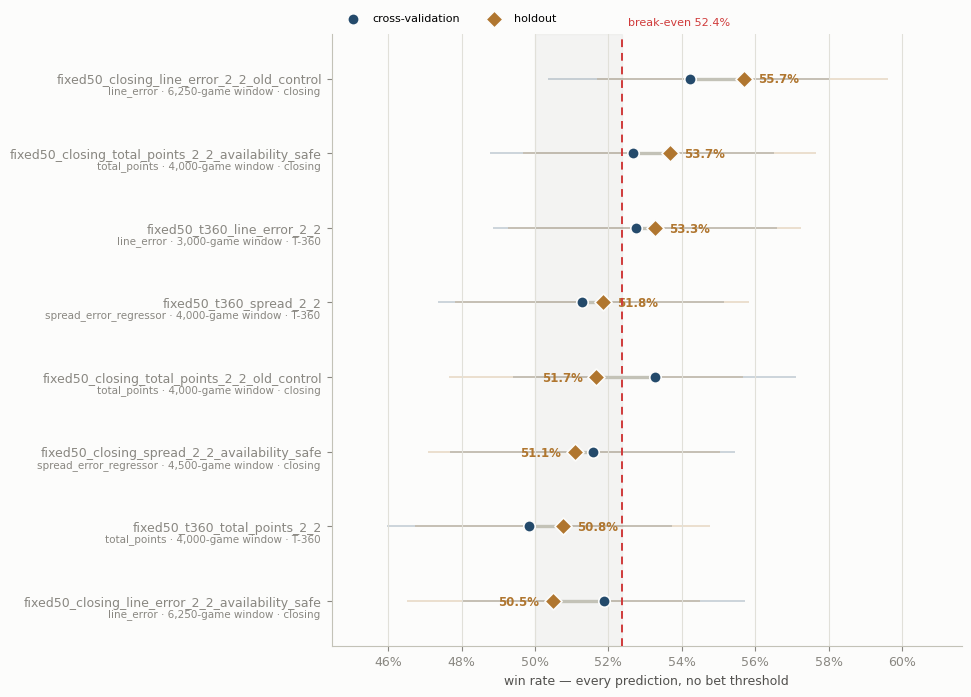

experiment_name,spec,cv_win_rate,holdout_win_rate,holdout_minus_cv,cv_n_bets,holdout_n_bets
fixed50_closing_line_error_2_2_old_control,"line_error · 6,250-game window · closing",54.22%,55.69%,+1.47%,643,609
fixed50_closing_total_points_2_2_availability_safe,"total_points · 4,000-game window · closing",52.66%,53.68%,+1.02%,643,609
fixed50_t360_line_error_2_2,"line_error · 3,000-game window · T-360",52.75%,53.28%,+0.53%,643,605
fixed50_t360_spread_2_2,"spread_error_regressor · 4,000-game window · T-360",51.27%,51.85%,+0.58%,639,605
fixed50_closing_total_points_2_2_old_control,"total_points · 4,000-game window · closing",53.28%,51.67%,-1.61%,643,609
fixed50_closing_spread_2_2_availability_safe,"spread_error_regressor · 4,500-game window · closing",51.57%,51.08%,-0.49%,643,609
fixed50_t360_total_points_2_2,"total_points · 4,000-game window · T-360",49.84%,50.76%,+0.91%,639,605
fixed50_closing_line_error_2_2_availability_safe,"line_error · 6,250-game window · closing",51.88%,50.50%,-1.37%,643,609


In [4]:
# `scoreboard` is built in the setup cell -- same frame, no bet threshold.
coverage.plot_scoreboard(scoreboard)
plt.show()

display(
    scoreboard[[
        'experiment_name', 'spec', 'cv_win_rate', 'holdout_win_rate',
        'holdout_minus_cv', 'cv_n_bets', 'holdout_n_bets',
    ]]
    .iloc[::-1]
    .style.format({
        'cv_win_rate': '{:.2%}',
        'holdout_win_rate': '{:.2%}',
        'holdout_minus_cv': '{:+.2%}',
    }, na_rep='—')
    .hide(axis='index')
)

## 2. The operating point

Sections 2 and 3 bet **every game** -- no margin cutoff. A raw threshold like
`0.5` points answers a different question for every model anyway, because their
score distributions differ, so the rule here is expressed as **coverage**, and
the coverage is 100%.

That is a deliberate choice, not a default. Selectivity is a real question, but
it is section 4's question: there the same ranking is cut into coverage bands
and disjoint buckets, and §4.3 learns a cutoff on CV, freezes it, and applies it
forward -- the only version you could actually have bet. Filtering here as well
would mean section 4 was already reading a pre-filtered field.

Set `OPERATING_COVERAGE` below 1.00 to restore a cutoff: it is found on CV,
frozen, and applied unchanged to holdout, so holdout never influences it.
Regressor cutoffs are in points and classifier cutoffs in expected-value units,
so those two numbers are never comparable directly -- only their coverage is.

In [5]:
operating = coverage.operating_point_table(
    runs, predictions, coverage_level=OPERATING_COVERAGE
)
if operating.attrs.get('missing_calibration'):
    display(Markdown(
        '⚠️ Excluded, no usable cross-validation predictions: '
        + ', '.join(f'`{name}`' for name in operating.attrs['missing_calibration'])
    ))
display(
    operating.pivot_table(
        index=['label', 'cutoff', 'cutoff_units'],
        columns='source',
        values=['realised_coverage', 'win_rate'],
    ).round(4)
)

realised_coverage  \
source                                                                                                        cross-validation   
label                                                                                  cutoff   cutoff_units                     
Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360 0.213359 points                  0.8989   
Predicts error vs bookmaker line · 6,250-game window                                   0.183231 points                  0.8989   
Predicts error vs bookmaker line · 6,250-game window · 2.0-data                        0.191884 points                  0.8989   
Predicts final total points · 4,000-game window                                        0.179184 points                  0.8989   
Predicts final total points · 4,000-game window · 2.0-data                             0.230591 points                  0.8989   
Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360      0.260040 points                  0.8998   
spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360           0.235388 points                  0.8998   
spread error regressor · 4,500-game window                                             0.163230 points                  0.8989   

                                                                                                                      \
source                                                                                                       holdout   
label                                                                                  cutoff   cutoff_units           
Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360 0.213359 points        0.9025   
Predicts error vs bookmaker line · 6,250-game window                                   0.183231 points        0.8522   
Predicts error vs bookmaker line · 6,250-game window · 2.0-data                        0.191884 points        0.9195   
Predicts final total points · 4,000-game window                                        0.179184 points        0.8867   
Predicts final total points · 4,000-game window · 2.0-data                             0.230591 points        0.8555   
Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360      0.260040 points        0.9140   
spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360           0.235388 points        0.8959   
spread error regressor · 4,500-game window                                             0.163230 points        0.9179   

                                                                                                                     win_rate  \
source                                                                                                       cross-validation   
label                                                                                  cutoff   cutoff_units                    
Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360 0.213359 points                 0.5227   
Predicts error vs bookmaker line · 6,250-game window                                   0.183231 points                 0.5235   
Predicts error vs bookmaker line · 6,250-game window · 2.0-data                        0.191884 points                 0.5478   
Predicts final total points · 4,000-game window                                        0.179184 points                 0.5252   
Predicts final total points · 4,000-game window · 2.0-data                             0.230591 points                 0.5496   
Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360      0.260040 points                 0.4965   
spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360           0.235388 points                 0.5212   
spread error regressor · 4,500-game window                         

## 3. Headline: CV versus holdout win rate, plus flat-odds ROI

CV and holdout win rates are plotted together so any out-of-sample drop is
visible directly. The error bars are **95% Wilson confidence intervals** around
each observed win rate. They represent sampling uncertainty from the finite
number of decided bets -- not variation across seeds, folds, or individual
prediction errors. Pushes are excluded, and holdout intervals are usually wider
because holdout has fewer games.

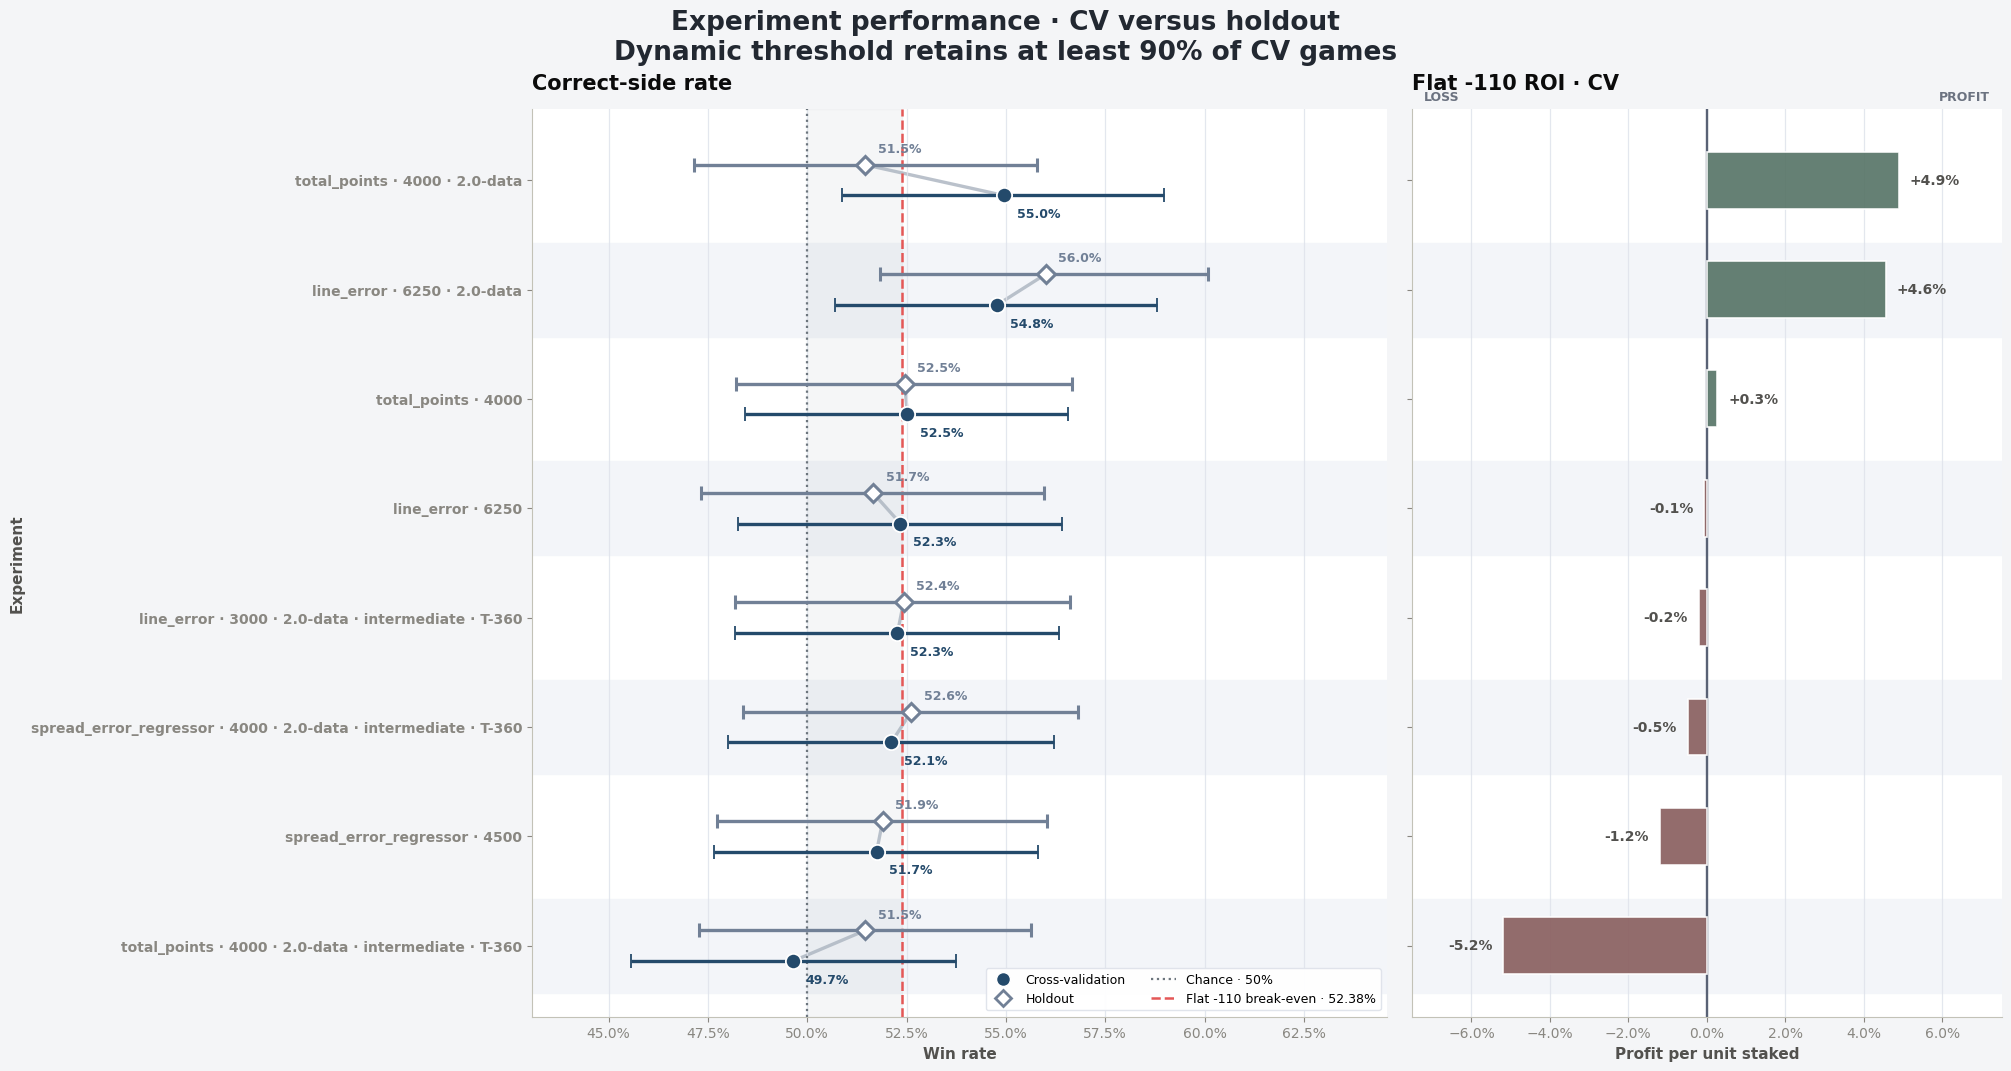

,label,cutoff,cutoff_units,cv_kept,cv_candidates,cv_bets,cv_win_rate,cv_ci_low,cv_ci_high,cv_flat_roi,holdout_kept,holdout_candidates,holdout_bets,holdout_win_rate,holdout_ci_low,holdout_ci_high,holdout_flat_roi
0,"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",0.1919,points,89.9%,643,578,54.78%,50.70%,58.81%,4.56%,92.0%,609,560,56.00%,51.82%,60.09%,6.79%
1,"spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360",0.2354,points,90.0%,639,575,52.12%,48.00%,56.21%,-0.49%,89.6%,605,542,52.62%,48.38%,56.82%,0.45%
2,"Predicts final total points · 4,000-game window",0.1792,points,89.9%,643,578,52.52%,48.44%,56.57%,0.27%,88.7%,609,540,52.45%,48.20%,56.67%,0.13%
3,"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",0.2134,points,89.9%,643,578,52.27%,48.18%,56.34%,-0.20%,90.2%,605,546,52.43%,48.20%,56.62%,0.08%
4,"spread error regressor · 4,500-game window",0.1632,points,89.9%,643,578,51.75%,47.66%,55.82%,-1.20%,91.8%,609,559,51.90%,47.74%,56.04%,-0.91%
5,"Predicts error vs bookmaker line · 6,250-game window",0.1832,points,89.9%,643,578,52.35%,48.26%,56.40%,-0.06%,85.2%,609,519,51.66%,47.34%,55.95%,-1.37%
6,"Predicts final total points · 4,000-game window · 2.0-data",0.2306,points,89.9%,643,578,54.96%,50.87%,58.98%,4.89%,85.6%,609,521,51.47%,47.14%,55.77%,-1.71%
7,"Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360",0.2600,points,90.0%,639,575,49.65%,45.57%,53.74%,-5.19%,91.4%,605,553,51.47%,47.28%,55.63%,-1.73%


In [6]:
charts.plot_headline_win_rate_and_roi(
    operating, operating_coverage=OPERATING_COVERAGE, label_col='panel'
)
plt.show()

display(
    coverage.headline_table(operating).style.format({
        'cutoff': '{:.4f}',
        **{f'{side}_{field}': fmt
           for side in ('cv', 'holdout')
           for field, fmt in (
               ('kept', '{:.1%}'), ('win_rate', '{:.2%}'),
               ('ci_low', '{:.2%}'), ('ci_high', '{:.2%}'), ('flat_roi', '{:.2%}'),
           )},
    }, na_rep='—')
)

## 4. Does the margin of the prediction predict winning?

This is the question behind "should I only bet when the model is confident?".

The model's margin is `selection_score`: `|predicted edge|` in points for a
regressor, expected value for the classifier. A margin near zero means the model
expects the game to land on the line, so it has no opinion worth acting on. The
hope is that dropping those raises the win rate on what is left.

Everything here is expressed in **coverage** -- "keep the top 60% by margin" --
never in a raw threshold. A cutoff of 2.0 points keeps 36% of one run's games and
71% of another's, so a shared numeric threshold silently compares two different
selectivities and reads as a model difference.

Two cuts of the same ranking, because they fail differently:

- **Cumulative** (§4.2): the top *x*% of games. This is the shape of the
  decision, but every cut shares most of its games with the one above it, so the
  curve moves as a block and "top 60% beats top 100%" is largely a set compared
  with itself.
- **Disjoint bands** (§4.2, bar chart): the same ranking cut into ten equal,
  non-overlapping slices. These really are independent samples, so a trend
  across them means something and carries an honest p-value.

Read §4.1 and §4.2 as **description**: they rank holdout by holdout's own
margins, which is choosing a threshold in-sample. §4.3 is the executable
version -- cutoff learned on CV, frozen, applied forward. If a run looks good in
§3.2 and not in §3.3, the effect did not survive having to be chosen in advance,
which is the only way you could ever have used it.

In [7]:
views = coverage.build_views(
    runs, predictions,
    coverage_grid=COVERAGE_GRID, n_buckets=N_MARGIN_BUCKETS,
)
self_coverage, cv_coverage, buckets, trends = views

print(
    f'{len(self_coverage):,} coverage rows, {len(buckets):,} bucket rows '
    f'across {runs["label"].nunique()} run(s).'
)

160 coverage rows, 160 bucket rows across 8 run(s).


### 4.1 Every run

Faceted rather than overlaid: runs of the same strategy share a colour in this
project's palette, so a single panel would make identity ambiguous exactly where
the lines cross. All panels share one y axis, which is what makes them
comparable.

A rising line left-to-right means margin is picking winners. A flat line means
the margin is noise and selectivity buys nothing but a smaller sample -- watch
for intervals widening towards the right of every panel, which is the sample
shrinking, not the model improving.

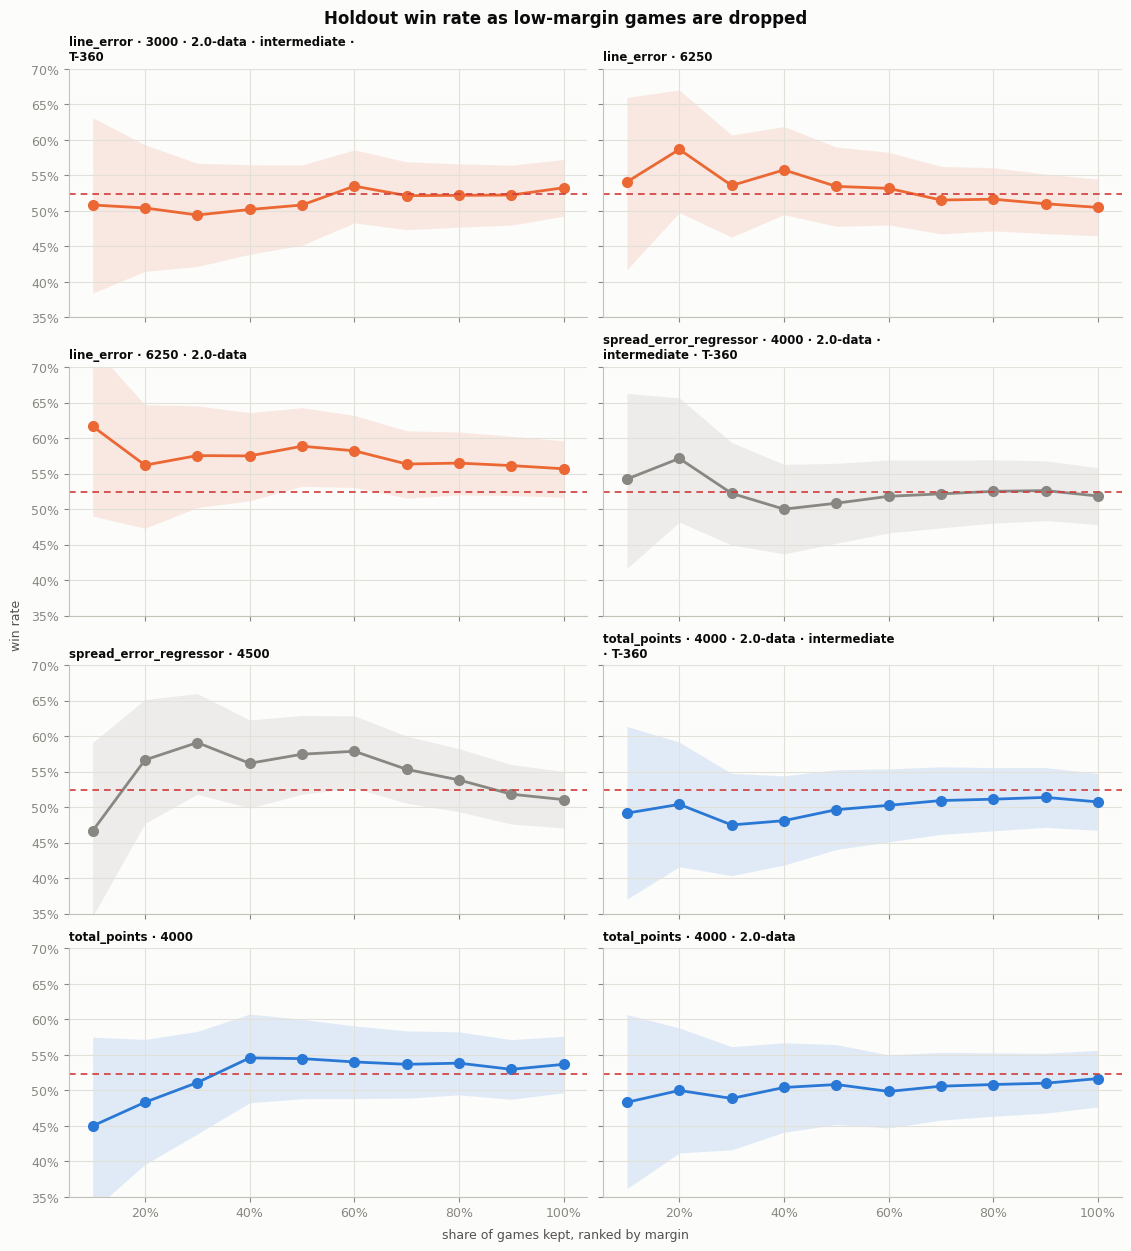

label,n_decided,independent,spearman_rho,spearman_p,top_half_win_rate,bottom_half_win_rate,half_gap,half_gap_p
"spread error regressor · 4,500-game window",603,True,+0.122,0.003,57.48%,44.70%,+12.77%,0.002
"Predicts error vs bookmaker line · 6,250-game window",598,True,+0.079,0.052,53.51%,47.49%,+6.02%,0.141
"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",598,True,+0.042,0.303,58.86%,52.51%,+6.35%,0.118
"spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360",596,True,+0.011,0.783,51.01%,52.68%,-1.68%,0.682
"Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360",595,True,-0.015,0.722,49.49%,52.01%,-2.52%,0.539
"Predicts final total points · 4,000-game window",598,True,-0.018,0.659,54.52%,52.84%,+1.67%,0.682
"Predicts final total points · 4,000-game window · 2.0-data",598,True,-0.038,0.359,50.84%,52.51%,-1.67%,0.682
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",595,True,-0.038,0.349,50.84%,55.70%,-4.86%,0.235


A positive `spearman_rho` with a small `spearman_p` would mean higher margin really does go with winning more often. `half_gap` is the same question asked of two **disjoint** halves of the holdout, so its p-value is a legitimate two-sample test rather than a set compared with itself. Where `independent` is False the p-values are anti-conservative by an unknown factor and must not be quoted.

In [8]:
fig, _ = coverage.plot_coverage_small_multiples(
    self_coverage.assign(label=self_coverage['panel']),
    source='holdout', ylim=WIN_RATE_YLIM,
)
fig.suptitle(
    'Holdout win rate as low-margin games are dropped',
    fontsize=12, fontweight='semibold', color=theme.INK,
)
plt.show()

display(
    trends[trends['source'] == 'holdout']
    .drop(columns=['source'])
    .sort_values('spearman_rho', ascending=False)
    .style.format({
        'spearman_rho': '{:+.3f}', 'spearman_p': '{:.3f}',
        'top_half_win_rate': '{:.2%}', 'bottom_half_win_rate': '{:.2%}',
        'half_gap': '{:+.2%}', 'half_gap_p': '{:.3f}',
    }, na_rep='—')
    .hide(axis='index')
)
display(Markdown(
    'A positive `spearman_rho` with a small `spearman_p` would mean higher '
    'margin really does go with winning more often. `half_gap` is the same '
    'question asked of two **disjoint** halves of the holdout, so its p-value '
    'is a legitimate two-sample test rather than a set compared with itself. '
    'Where `independent` is False the p-values are anti-conservative by an '
    'unknown factor and must not be quoted.'
))

### 4.2 Per run: the cut you would make, and the bands underneath it

For each run: the cumulative curve with the bet volume it costs, then the ten
disjoint margin bands. The bands are the honest version of the same data -- if
the leftmost bars do not stand clear of the rightmost ones, there is no
threshold to find, whatever the cumulative curve appears to do.

Wilson intervals are drawn only where rows are independent. Pooled-snapshot runs
get no band at all, because one game there contributes ~10 correlated rows and a
binomial interval over them would be far too narrow.

In [9]:
# for label in runs['label']:
#     curve = self_coverage[self_coverage['label'] == label]
#     if curve.empty:
#         continue
#     display(Markdown(f'#### {label}'))
#     coverage.plot_coverage_curve(
#         curve, title='Cumulative: keep the top x% by margin', ylim=WIN_RATE_YLIM
#     )
#     plt.show()

#     holdout_buckets = buckets[
#         (buckets['label'] == label) & (buckets['source'] == 'holdout')
#     ].reset_index(drop=True)
#     if not holdout_buckets.empty:
#         coverage.plot_margin_buckets(
#             holdout_buckets,
#             title='Disjoint: holdout win rate within each margin band',
#         )
#         plt.show()

#     display(
#         curve.pivot_table(
#             index='target_coverage', columns='source',
#             values=['realised_coverage', 'n_bets', 'win_rate', 'roi'],
#         )
#         .sort_index(ascending=False)
#         .style.format('{:.3f}', na_rep='—')
#     )

### 4.3 What you could actually have bet

Each row takes a target share of **CV** games, derives the CV cutoff, then
applies that same number to holdout. Holdout never influences the cutoff, so
`holdout_win` is a forward check rather than another criterion for choosing one.

`holdout_kept` drifts away from `target_coverage`, and the drift is itself
information: it says the two periods' score distributions differ, so a cutoff
calibrated on one does not keep the same share of the other.

Read `holdout_bets` beside `holdout_win`. Compare `holdout_ci_low` against
break-even (52.38%): a win rate whose lower bound sits below it has not been
shown to beat the vig, however good the point estimate looks. At ~415 holdout
games a 20% cut is ~80 bets, where a 60% win rate is four games away from a 50%
one.

In [10]:
executable = coverage.executable_table(cv_coverage)
if executable.empty:
    display(Markdown('_No cross-validation predictions, so no cutoff can be frozen._'))
else:
    display(executable.style.format({
        'target_coverage': '{:.0%}', 'cutoff': '{:.4f}',
        'cv_kept': '{:.1%}', 'cv_win': '{:.2%}', 'cv_flat_roi': '{:.2%}',
        'holdout_kept': '{:.1%}', 'holdout_win': '{:.2%}',
        'holdout_ci_low': '{:.2%}', 'holdout_flat_roi': '{:.2%}',
        'holdout_win_vs_full': '{:+.2%}',
    }, na_rep='—').hide(axis='index'))

    # Only runs with one row per game are eligible: on a pooled-snapshot run
    # holdout_bets counts one game up to ten times, so a 100-bet floor there is
    # really a 10-game floor and there is no interval to judge it against.
    eligible = executable[
        executable['independent'].fillna(False)
        & (executable['holdout_bets'].fillna(0) >= 100)
    ]
    if not eligible.empty:
        best = eligible.sort_values('holdout_win', ascending=False).iloc[0]
        display(Markdown(
            f"Best holdout win rate at ≥100 bets: **{best['holdout_win']:.2%}** "
            f"for `{best['label']}` at {best['target_coverage']:.0%} CV coverage "
            f"(cutoff {best['cutoff']:.3f} {best['cutoff_units']}, "
            f"{int(best['holdout_bets'])} bets, 95% lower bound "
            f"{best['holdout_ci_low']:.2%} against a {theme.BREAK_EVEN:.2%} "
            f"break-even). This row is the maximum over {len(eligible)} eligible "
            'rows, so treat it as the best-looking cell of a search rather than '
            'as an estimate — and check whether its lower bound clears '
            'break-even before believing any of it.'
        ))

label,target_coverage,cutoff,cutoff_units,cv_kept,cv_bets,cv_win,cv_flat_roi,holdout_kept,holdout_bets,holdout_win,holdout_ci_low,holdout_flat_roi,holdout_win_vs_full,independent
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",100%,0.0005,points,100.0%,643,52.75%,0.69%,100.0%,605,53.28%,49.26%,1.68%,+0.00%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",90%,0.2134,points,89.9%,578,52.27%,-0.20%,90.2%,546,52.43%,48.20%,0.08%,-0.85%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",80%,0.4148,points,79.9%,514,52.36%,-0.04%,79.0%,478,52.23%,47.72%,-0.29%,-1.05%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",70%,0.6578,points,70.0%,450,52.36%,-0.04%,67.3%,407,52.87%,47.98%,0.92%,-0.41%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",60%,0.9164,points,60.0%,386,51.57%,-1.53%,55.5%,336,52.12%,46.74%,-0.49%,-1.16%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",50%,1.1694,points,50.1%,322,52.66%,0.54%,46.1%,279,51.82%,45.92%,-1.04%,-1.45%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",40%,1.4382,points,40.0%,257,54.51%,4.03%,36.0%,218,50.00%,43.36%,-4.46%,-3.28%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",30%,1.6911,points,30.0%,193,53.40%,1.93%,27.8%,168,49.39%,41.84%,-5.57%,-3.89%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",20%,1.9927,points,20.1%,129,53.12%,1.41%,20.3%,123,50.42%,41.57%,-3.62%,-2.86%,True
"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360",10%,2.6216,points,10.1%,65,50.77%,-3.08%,9.6%,58,50.00%,37.33%,-4.39%,-3.28%,True


Best holdout win rate at ≥100 bets: **58.73%** for `spread error regressor · 4,500-game window` at 30% CV coverage (cutoff 1.277 points, 191 bets, 95% lower bound 51.61% against a 52.38% break-even). This row is the maximum over 70 eligible rows, so treat it as the best-looking cell of a search rather than as an estimate — and check whether its lower bound clears break-even before believing any of it.

## 5. Configuration sanity check

Only result-affecting fields that vary across the selected runs are shown. This
is a compact guard against attributing a difference to the model when another
setting changed at the same time.

In [11]:
substantive = loaders.config_matrix(runs, ignore=loaders.LABEL_ONLY_CONFIG_KEYS)
display(
    substantive
    if not substantive.empty
    else Markdown('_No result-affecting configuration differences._')
)

,"Predicts error vs bookmaker line · 3,000-game window · 2.0-data · intermediate · T-360","Predicts error vs bookmaker line · 6,250-game window","Predicts error vs bookmaker line · 6,250-game window · 2.0-data","spread error regressor · 4,000-game window · 2.0-data · intermediate · T-360","spread error regressor · 4,500-game window","Predicts final total points · 4,000-game window · 2.0-data · intermediate · T-360","Predicts final total points · 4,000-game window","Predicts final total points · 4,000-game window · 2.0-data"
betting.away_price_col,None,None,None,None,ODDS_SPREAD_PRICE_AWAY,None,None,None
betting.comparison_line_cols,"[""ODDS_CLOSING_TOTAL_LINE_bet365""]","[""ODDS_TOTAL_LINE_consensus_opener""]","[""ODDS_TOTAL_LINE_consensus_opener""]","[""ODDS_CLOSING_SPREAD_LINE_HOME_bet365""]","[""ODDS_SPREAD_LINE_HOME_consensus_opener""]","[""ODDS_CLOSING_TOTAL_LINE_bet365""]","[""ODDS_TOTAL_LINE_consensus_opener""]","[""ODDS_TOTAL_LINE_consensus_opener""]"
betting.home_price_col,None,None,None,None,ODDS_SPREAD_PRICE_HOME,None,None,None
data.csv_path,data/train_data/intermediate_line_data_2_2_20260901.csv,data/train_data/training_data_2_2_20260907_availability_safe.csv,data/train_data/training_data_2_2_20260901.csv,data/train_data/intermediate_line_data_2_2_20260901.csv,data/train_data/training_data_2_2_20260907_availability_safe.csv,data/train_data/intermediate_line_data_2_2_20260901.csv,data/train_data/training_data_2_2_20260907_availability_safe.csv,data/train_data/training_data_2_2_20260901.csv
data.dataset_type,intermediate_line,closing_line,closing_line,intermediate_line,closing_line,intermediate_line,closing_line,closing_line
data.scoring_csv_path,data/train_data/intermediate_line_data_2_2_20260901_scoring.csv,None,None,data/train_data/intermediate_line_data_2_2_20260901_scoring.csv,None,data/train_data/intermediate_line_data_2_2_20260901_scoring.csv,None,None
data.snapshot_minutes,360,None,None,360,None,360,None,None
line_col,None,None,None,None,None,ODDS_TOTAL_LINE_bet365,ODDS_TOTAL_LINE_bet365,ODDS_TOTAL_LINE_bet365
prediction_strategy,line_error_regressor,line_error_regressor,line_error_regressor,spread_error_regressor,spread_error_regressor,total_points_regressor,total_points_regressor,total_points_regressor
target_family,line_error,line_error,line_error,spread_error,spread_error,total_points,total_points,total_points


## 6. Counterfactual: closing-line models settled at T-360

**This is not a fair test, and it is here as a diagnostic rather than as a
strategy.** Each closing-line model's holdout picks are re-settled against the
line quoted six hours before tip-off. The picks themselves are unchanged: only
the price they settle into moves, and the side is re-taken against the new
line, because a game liked by half a point against the close can be an UNDER
against a line that has since moved up.

Two leaks, both optimistic, both unavoidable in this construction:

1. **The decision uses information from after the price.** The features are the
   closing-line dataset's, so the pick is made with knowledge the market only
   had at the close. It could not have been made at T-360.
2. **For `line_error_regressor` the target is anchored to the close.** Its
   prediction *is* `TOTAL - closing_line`, so recovering an implied total puts
   the closing line directly into the number then compared against the earlier
   line. There the closing line is half the prediction, not just a scoring
   choice.

So read the gap as an upper bound on what an earlier price could be worth. The
honest version of this question is a model trained on the intermediate-line
dataset — the pooled and T-360 runs already in this survey.

Predictions carry no `GAME_ID`, so they are joined back to their games on
`(date, final total, settlement line)`, and any key that is not unique in the
source CSV is discarded rather than matched to its first hit. The join and
movement table below reports what that cost.

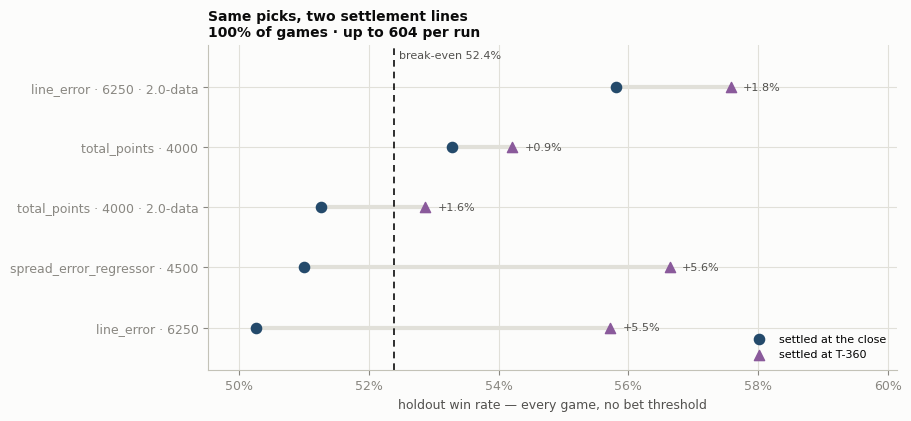

#### 6.2 The same comparison swept by margin

#### Predicts error vs bookmaker line · 6,250-game window

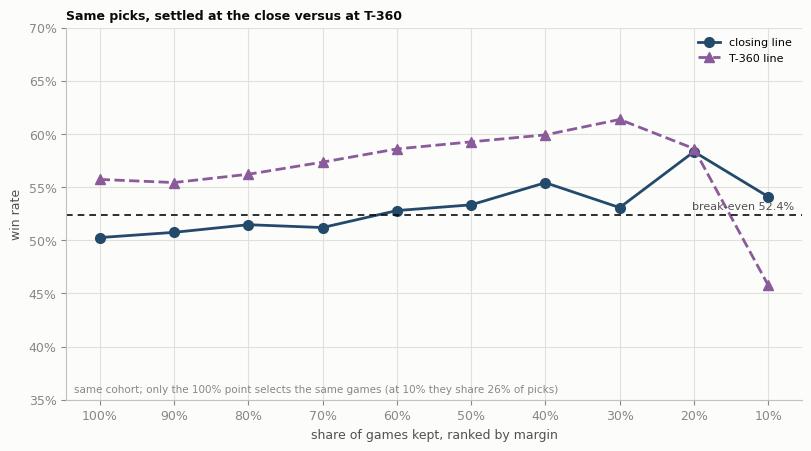

#### Predicts error vs bookmaker line · 6,250-game window · 2.0-data

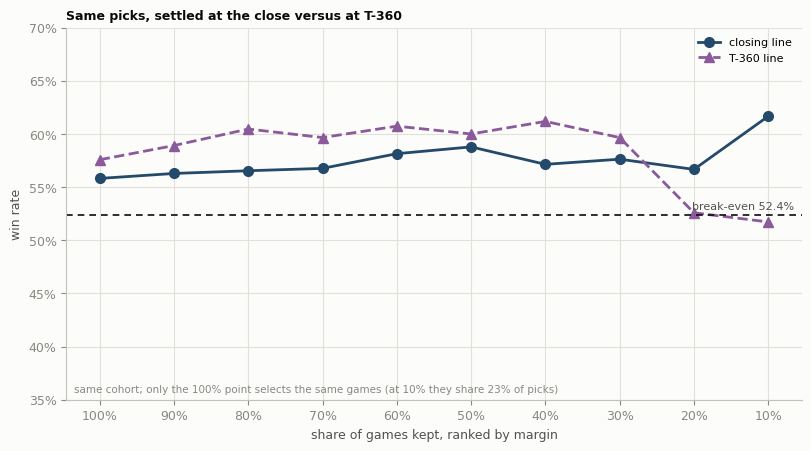

#### spread error regressor · 4,500-game window

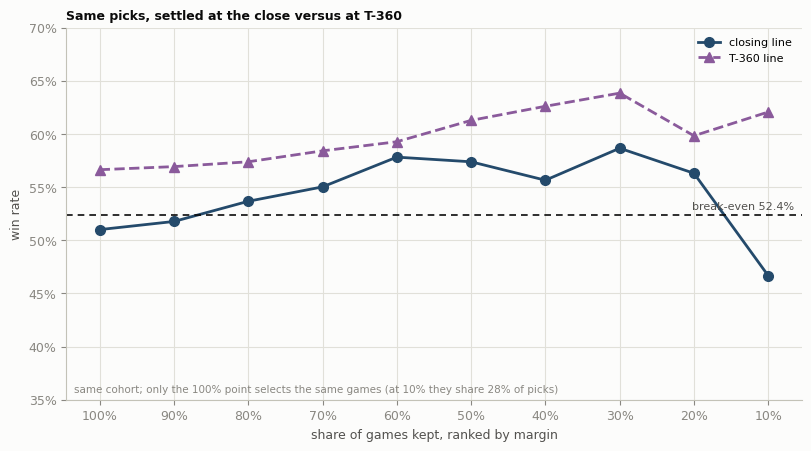

#### Predicts final total points · 4,000-game window

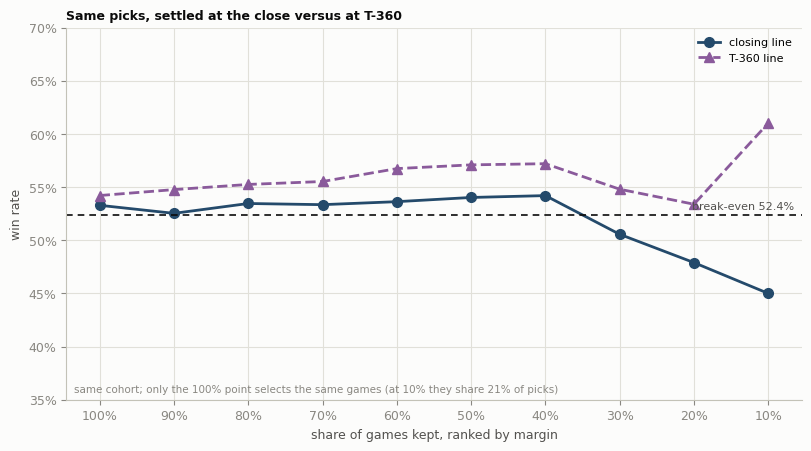

#### Predicts final total points · 4,000-game window · 2.0-data

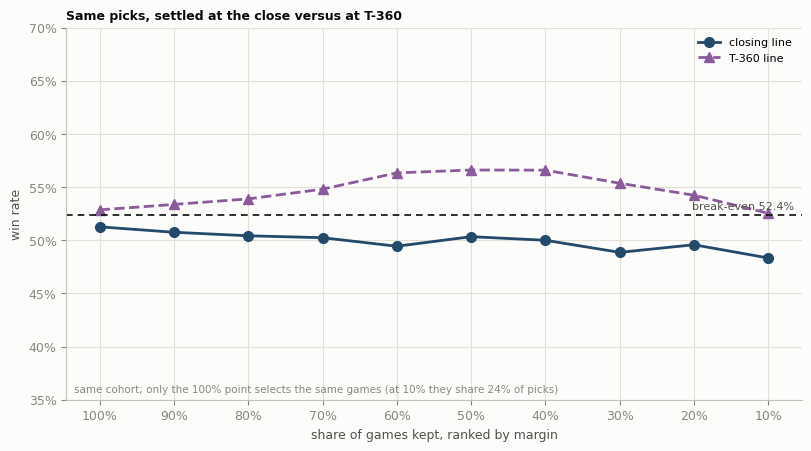

**Join and line movement.** Both series are drawn from the same cohort — only games holding a `T-360` line, on both sides. But they are only the *same games* at 100% coverage. Below that each series keeps its own top share by its own margin, and swapping the settlement line re-ranks the games: at the thinnest cut the two selections share just 26% of their picks. So read 6.1 as the clean comparison and the sweep in 6.2 as confounded by a changing subset — the `share_selection_shared` column says by how much.

label,n_predictions,n_matched,n_unmatched,n_ambiguous_keys_in_source,n_with_T-360_line,n_games,mean_abs_line_move,share_line_moved,n_side_flips,share_side_flipped
"Predicts error vs bookmaker line · 6,250-game window",609,609,0,266,604,604,1.20,79.6%,148,24.5%
"Predicts error vs bookmaker line · 6,250-game window · 2.0-data",609,609,0,266,604,604,1.20,79.6%,125,20.7%
"spread error regressor · 4,500-game window",609,609,0,370,604,604,0.86,72.5%,118,19.5%
"Predicts final total points · 4,000-game window",609,609,0,266,604,604,1.20,79.6%,137,22.7%
"Predicts final total points · 4,000-game window · 2.0-data",609,609,0,266,604,604,1.20,79.6%,161,26.7%


At full coverage, 5 of 5 run(s) have overlapping 95% intervals between the two settlement lines, so the gap is within sampling noise for those. Remember what this measures: a pick made with closing-line information, priced at T-360. It is an upper bound on what an earlier price could be worth, not a strategy — the intermediate-line runs in section 4 are the honest version of the same question.

In [12]:
report = alt_line.settlement_report(
    runs, predictions,
    project_root=PROJECT_ROOT,
    snapshot_csv=ALT_LINE_SNAPSHOT_CSV,
    snapshot_minutes=ALT_LINE_SNAPSHOT_MINUTES,
    snapshot_book=ALT_LINE_BOOK,
    coverage_grid=COVERAGE_GRID,
)
alt_name = f'T-{ALT_LINE_SNAPSHOT_MINUTES}'

if report.comparisons.empty:
    display(Markdown('_No closing-line regressor runs in this survey._'))
else:
    # 6.1 -- the whole section in one picture, at 100% coverage only. That is
    # the one coverage where both series provably score the SAME games, so the
    # horizontal gap is the settlement line and nothing else.
    alt_line.plot_settlement_summary(
        report.comparisons, alt_name=alt_name, coverage_level=1.0,
        label_map=runs.set_index('label')['panel_label'].to_dict(),
    )
    plt.show()

    display(Markdown('#### 6.2 The same comparison swept by margin'))
    for label, comparison in report.comparisons.groupby('label', sort=False):
        display(Markdown(f'#### {label}'))
        alt_line.plot_settlement_comparison(
            comparison,
            title=f'Same picks, settled at the close versus at {alt_name}',
            ylim=WIN_RATE_YLIM,
        )
        plt.show()

    shared_at_thinnest = (
        report.comparisons.groupby('target_coverage')['share_selection_shared']
        .first().sort_index().iloc[0]
    )
    display(Markdown(
        '**Join and line movement.** Both series are drawn from the same '
        'cohort — only games holding a '
        f'`{alt_name}` line, on both sides. But they are only the *same games* '
        'at 100% coverage. Below that each series keeps its own top share by '
        'its own margin, and swapping the settlement line re-ranks the games: '
        f'at the thinnest cut the two selections share just '
        f'{shared_at_thinnest:.0%} of their picks. So read 6.1 as the clean '
        'comparison and the sweep in 6.2 as confounded by a changing subset — '
        'the `share_selection_shared` column says by how much.'
    ))
    display(report.joins.style.format({
        'mean_abs_line_move': '{:.2f}',
        'share_line_moved': '{:.1%}',
        'share_side_flipped': '{:.1%}',
    }, na_rep='—').hide(axis='index'))

    gap = alt_line.settlement_gap(report.comparisons, alt_name=alt_name)
    display(gap.style.format({
        ('target_coverage', ''): '{:.0%}',
        **{(metric, column): '{:.2%}'
           for metric in ('win_rate', 'roi')
           for column in ('closing line', f'{alt_name} line', 'gain')},
    }, na_rep='—').hide(axis='index'))

    full = report.comparisons[
        report.comparisons['target_coverage'] == max(COVERAGE_GRID)
    ]
    overlaps = [
        label for label, group in full.groupby('label')
        if group['win_rate_ci_low'].max() < group['win_rate_ci_high'].min()
    ]
    display(Markdown(
        f'At full coverage, {len(overlaps)} of {full["label"].nunique()} run(s) '
        'have overlapping 95% intervals between the two settlement lines, so '
        'the gap is within sampling noise for those. Remember what this '
        f'measures: a pick made with closing-line information, priced at '
        f'{alt_name}. It is an upper bound on what an earlier price could be '
        'worth, not a strategy — the intermediate-line runs in section 4 are '
        'the honest version of the same question.'
    ))